In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import random
import copy
import ot
#Setting a random seed to ensure experiments are reproducible
seed=42
# 1. Python random
random.seed(seed)

# 2. NumPy
np.random.seed(seed)

# 3. PyTorch (CPU)
torch.manual_seed(seed)

# 4. PyTorch (GPU)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# 5. Deterministic behavior
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


In [2]:
def createIHDPTensorDataset(data_dir):
    npz=np.load(data_dir)
    X = torch.tensor(npz["x"][:, :, 0], dtype=torch.float32)
    y = torch.tensor(npz["yf"][:, 0], dtype=torch.float32)
    t = torch.tensor(npz["t"][:, 0], dtype=torch.float32)

    return TensorDataset(X,t,y)

def create_ihdp_rct_obs_datasets(
    npz_path,
    replication=0,
    rct_fraction=0.2,
    seed=42,
    bias_strength=1.0,
    noise_std=0.1,
    standardize_for_propensity=True,
    return_numpy=False
):
    """
    Split one IHDP training replication into an RCT-like subset and an OBS-like subset
    with confounding.

    Parameters
    ----------
    npz_path : str
        Path to IHDP .npz file.
    replication : int
        Which replication/simulation index to use.
    rct_fraction : float
        Fraction of samples assigned to the RCT subset.
    seed : int
        Random seed for reproducibility.
    bias_strength : float
        Strength of confounding in OBS treatment assignment.
        Larger values => treatment depends more strongly on X.
    noise_std : float
        Std of Gaussian noise added to regenerated outcomes.
    standardize_for_propensity : bool
        Whether to z-score X before constructing OBS propensities.
    return_numpy : bool
        If True, also return numpy arrays/dictionaries.

    Returns
    -------
    rct_dataset : TensorDataset
        TensorDataset(X, t, yf, ycf, mu0, mu1)
    obs_dataset : TensorDataset
        TensorDataset(X, t, yf, ycf, mu0, mu1)

    Optionally also returns a dict of numpy arrays if return_numpy=True.

    Notes
    -----
    Expected keys in the IHDP npz:
        ['ate', 'mu1', 'mu0', 'yadd', 'yf', 'ycf', 't', 'x', 'ymul']

    Typical shapes:
        x   : (n, p, R)
        mu0 : (n, R)
        mu1 : (n, R)
        t   : (n, R)
        yf  : (n, R)
        ycf : (n, R)
    """

    rng = np.random.default_rng(seed)
    data = np.load(npz_path)

    required_keys = ["x", "mu0", "mu1"]
    for key in required_keys:
        if key not in data:
            raise ValueError(f"Missing required key '{key}' in npz file.")

    # ---- Extract one replication ----
    X = data["x"][:, :, replication]          # shape: (n, p)
    mu0 = data["mu0"][:, replication]         # shape: (n,)
    mu1 = data["mu1"][:, replication]         # shape: (n,)

    n = X.shape[0]
    if not (0.0 < rct_fraction < 1.0):
        raise ValueError("rct_fraction must be between 0 and 1.")

    # ---- Random split into RCT vs OBS groups ----
    indices = rng.permutation(n)
    n_rct = int(round(rct_fraction * n))
    rct_idx = indices[:n_rct]
    obs_idx = indices[n_rct:]

    # ---- Construct propensity model for OBS subset ----
    X_obs = X[obs_idx].copy()

    if standardize_for_propensity:
        mean = X_obs.mean(axis=0, keepdims=True)
        std = X_obs.std(axis=0, keepdims=True)
        std[std < 1e-8] = 1.0
        X_for_prop = (X_obs - mean) / std
    else:
        X_for_prop = X_obs

    # Random linear score to induce confounding
    w = rng.normal(size=X_for_prop.shape[1])
    w = w / (np.linalg.norm(w) + 1e-8)

    logits_obs = bias_strength * (X_for_prop @ w)

    # Center logits for numerical stability / balanced-ish treatment rates
    logits_obs = logits_obs - logits_obs.mean()

    p_obs = 1.0 / (1.0 + np.exp(-logits_obs))
    t_obs = rng.binomial(1, p_obs).astype(np.float32)

    # ---- RCT subset gets randomized treatment ----
    t_rct = rng.binomial(1, 0.5, size=len(rct_idx)).astype(np.float32)

    # ---- Regenerate outcomes from mu0 / mu1 ----
    # Add small noise so this behaves like a semi-synthetic observed outcome
    eps_rct = rng.normal(0.0, noise_std, size=len(rct_idx))
    eps_obs = rng.normal(0.0, noise_std, size=len(obs_idx))

    mu0_rct, mu1_rct = mu0[rct_idx], mu1[rct_idx]
    mu0_obs, mu1_obs = mu0[obs_idx], mu1[obs_idx]

    yf_rct = t_rct * mu1_rct + (1.0 - t_rct) * mu0_rct + eps_rct
    ycf_rct = (1.0 - t_rct) * mu1_rct + t_rct * mu0_rct + eps_rct

    yf_obs = t_obs * mu1_obs + (1.0 - t_obs) * mu0_obs + eps_obs
    ycf_obs = (1.0 - t_obs) * mu1_obs + t_obs * mu0_obs + eps_obs

    # ---- Build tensors ----
    def to_tensor_dataset(X_part, t_part, yf_part, ycf_part, mu0_part, mu1_part):
        return TensorDataset(
            torch.tensor(X_part, dtype=torch.float32),
            torch.tensor(t_part, dtype=torch.float32),
            torch.tensor(yf_part, dtype=torch.float32),
            torch.tensor(ycf_part, dtype=torch.float32),
            torch.tensor(mu0_part, dtype=torch.float32),
            torch.tensor(mu1_part, dtype=torch.float32),
        )

    rct_dataset = to_tensor_dataset(
        X[rct_idx], t_rct, yf_rct, ycf_rct, mu0_rct, mu1_rct
    )
    obs_dataset = to_tensor_dataset(
        X[obs_idx], t_obs, yf_obs, ycf_obs, mu0_obs, mu1_obs
    )

    if return_numpy:
        extra = {
            "rct_idx": rct_idx,
            "obs_idx": obs_idx,
            "p_obs": p_obs,
            "t_rct": t_rct,
            "t_obs": t_obs,
            "tau_rct": mu1_rct - mu0_rct,
            "tau_obs": mu1_obs - mu0_obs,
        }
        return rct_dataset, obs_dataset, extra

    return rct_dataset, obs_dataset
IHDP_rct_train, IHDP_obs_train = create_ihdp_rct_obs_datasets(
    npz_path="C:\\Users\\evany\\Desktop\\MaLabRotation\\Data\\FredJoData\\ihdp_npci_1-100.train.npz",
    replication=0,
    rct_fraction=0.2,
    seed=42,
    bias_strength=1.5,
    noise_std=0.1
)
IHDP_test= createIHDPTensorDataset("C:\\Users\\evany\\Desktop\\MaLabRotation\\Data\\FredJoData\\ihdp_npci_1-100.test.npz")

Shape: torch.Size([538, 25])
Mean: tensor([-2.4195e-02,  3.7343e-03, -9.9325e-04, -1.8301e-02, -1.4940e-02,
         1.1849e-02,  4.8141e-01,  9.2937e-02,  5.5019e-01,  3.5688e-01,
         2.7323e-01,  2.1747e-01,  3.7175e-01,  1.4721e+00,  1.4870e-01,
         9.5725e-01,  6.1338e-01,  9.6097e-01,  1.3755e-01,  1.2639e-01,
         1.5799e-01,  7.4349e-02,  7.4349e-02,  1.2825e-01,  1.8030e-01])
Std: tensor([1.0020, 1.0088, 1.0403, 0.9936, 1.0399, 0.9897, 0.5001, 0.2906, 0.4979,
        0.4795, 0.4460, 0.4129, 0.4837, 0.4997, 0.3561, 0.2025, 0.4874, 0.1939,
        0.3447, 0.3326, 0.3651, 0.2626, 0.2626, 0.3347, 0.3848])
Min: tensor([-2.7313, -3.8008, -1.8503, -0.8796, -5.1304, -1.8515,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000,  0.0000,  0.0000,
         0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000])
Max: tensor([1.5055, 2.5954, 2.9904, 2.2443, 2.3716, 2.9514, 1.0000, 1.0000, 1.0000,
        1.0000, 1.000

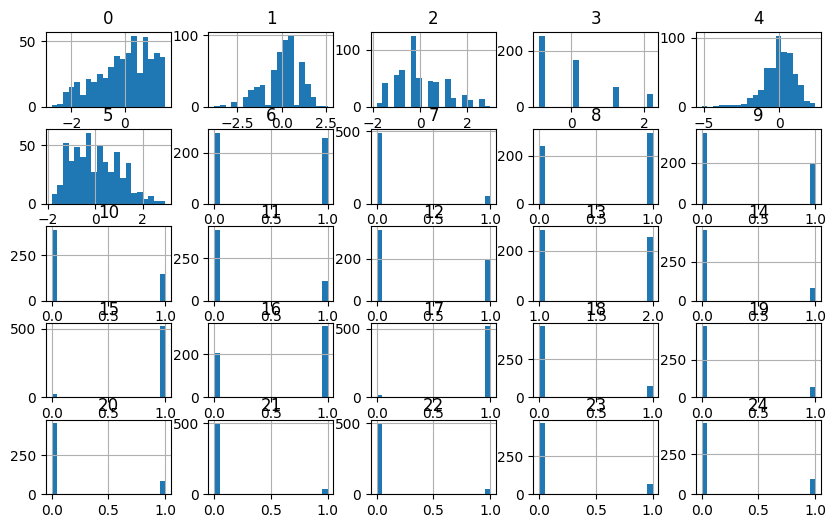

In [11]:
#Exploring the covariates X of the IHDP Dataset
def explore_tensor(X):
    print("Shape:", X.shape)
    print("Mean:", X.mean(dim=0))
    print("Std:", X.std(dim=0))
    print("Min:", X.min(dim=0).values)
    print("Max:", X.max(dim=0).values)

    import pandas as pd
    import matplotlib.pyplot as plt
    
    df = pd.DataFrame(X.numpy())
    df.hist(figsize=(10,6), bins=20)
    plt.show()

X_tensor = IHDP_obs_train.tensors[0]
explore_tensor(X_tensor)

Shape: torch.Size([538])
Mean: tensor(4.4298)
Std: tensor(2.2031)
Min: tensor(0.9112)
Max: tensor(8.3888)


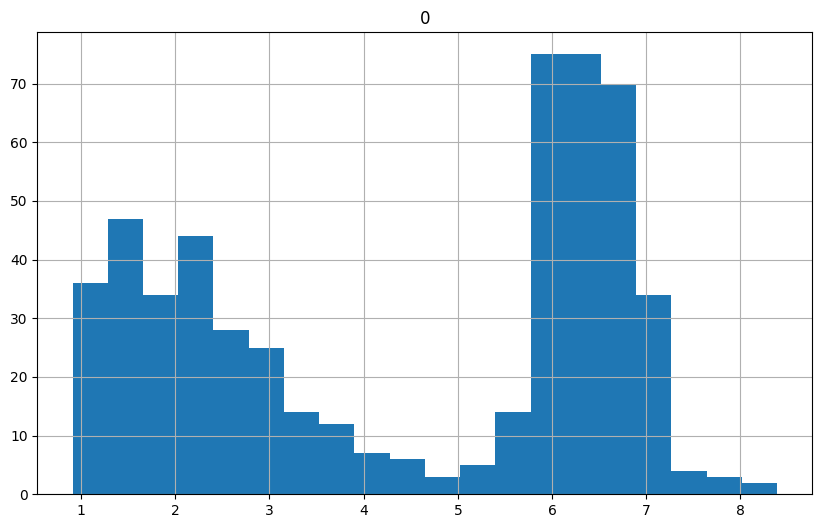

In [12]:
Y_tensor = IHDP_obs_train.tensors[2]
explore_tensor(Y_tensor)

In [5]:
#AutoEncoder: an Encoder paired with a Decoder to ensure x => z => x_recon is close
#Encoder: multi-layer feedforward network 
#Turns covariates X => representation Z

class AutoEncoder(nn.Module):
    def __init__(self,input_dim,hidden_dim,latent_dim):#,binary_index,cont_index
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), # Hidden layer 1
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2), #Hidden Layer 2
            nn.ReLU(),
            nn.Linear(hidden_dim//2,latent_dim)
        )
        '''
        Stage 1
        Contains 3 output heads
        1. Reconstruction head using a decoder
        2. 2 Pseudooutcome heads trained on OBS data
        3. Propenssity head
        '''
        #Output heads
        #Reconstruction head via decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim//2), # Hidden layer 1
            nn.ReLU(),
            nn.Linear(hidden_dim//2, hidden_dim), #Hidden Layer 2
            nn.ReLU(),
            nn.Linear(hidden_dim,input_dim)
        )


        #prospensity_head
        self.propensity_head= nn.Linear(latent_dim,1)

        #pseudo-outcome head, T=0, predicts a biased outcome estimation Y0
        self.t0_head =nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,1)
        )
        #pseudo-outcome head, T=1, predicts a biased outcome estimation Y1
        self.t1_head=nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim,1)
        )
        '''
        Stage 2
        1. Unconfounded outcome heads trained on RCT data
        '''
        self.g0_head = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

        self.g1_head = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )


        
    def forward(self,x):
        z = self.encoder(x) #representation Z

        
        t_logit = self.propensity_head(z)
        x_recon = self.decoder(z)

        #pseudooutcomes
        y0_pseudo=self.t0_head(z)
        y1_pseudo=self.t1_head(z)

        # Stage 2 unconfounded outcomes
        y0_rct = self.g0_head(z)
        y1_rct = self.g1_head(z)
        return {
            "x_recon" :x_recon,
            "t_logit" :t_logit,
            "y0_pseudo":y0_pseudo,
            "y1_pseudo":y1_pseudo,
            "y0_rct": y0_rct,
            "y1_rct":y1_rct
        }





In [6]:
def pseudo_outcome_loss(y0_hat, y1_hat, t_batch, y_batch, weights=None, outcome_type="continuous"):
    """
    Trains only the factual branch:
      - if t=0, compare y0_hat to y
      - if t=1, compare y1_hat to y
    """

    t_batch = t_batch.float()
    y_batch = y_batch.float()


    if outcome_type == "continuous":
        loss_fn = nn.MSELoss(reduction="none")
    elif outcome_type == "binary":
        loss_fn = nn.BCEWithLogitsLoss(reduction="none")
    else:
        raise ValueError("outcome_type must be 'continuous' or 'binary'")

    loss0 = loss_fn(y0_hat, y_batch)   # [B, 1]
    loss1 = loss_fn(y1_hat, y_batch)   # [B, 1]

    masked_loss = (1 - t_batch) * loss0 + t_batch * loss1
    #print("weights min:", weights.min().item())
    #print("weights max:", weights.max().item())
    #print("masked_loss min:", masked_loss.min().item())
    #print("masked_loss max:", masked_loss.max().item())
    if weights is not None:  
        masked_loss = weights * masked_loss  
    
    return masked_loss.mean()

In [13]:
#Training Functions
def detect_binary_continuous_columns(X_tensor, tol=1e-6):
    """
    Detect binary vs continuous columns automatically.

    A column is considered binary if its unique values are only {0,1}
    within numerical tolerance

    Returns index of continuous and binary columns
    """
    binary_idx = []
    continuous_idx = []

    n_features = X_tensor.shape[1]

    for i in range(n_features):
        col = X_tensor[:, i]
        unique_vals = torch.unique(col)

        # Round tiny numerical noise
        unique_vals = torch.round(unique_vals / tol) * tol

        # Check whether all unique values are 0 or 1
        is_binary = torch.all((unique_vals == 0) | (unique_vals == 1)).item()

        if is_binary:
            binary_idx.append(i)
        else:
            continuous_idx.append(i)

    return binary_idx, continuous_idx

def train_mixed_autoencoder(
    dataset,
    hidden_dim=8,
    latent_dim=4,
    batch_size=64,
    lr=1e-3,
    num_epochs=50,
    verbose=True,
    device=None
):
    """
    Train an autoencoder on a TensorDataset(X, t, y) or TensorDataset(X).

    Automatically detects binary and continuous columns in X and uses:
      - BCEWithLogitsLoss for binary columns
      - MSELoss for continuous columns

    Returns:
      model, history, binary_idx, continuous_idx
    """

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Extract X_tensor from TensorDataset
    if not hasattr(dataset, "tensors"):
        raise ValueError("dataset must be a TensorDataset")

    X_tensor = dataset.tensors[0].float()

    # Detect column types
    binary_idx, continuous_idx = detect_binary_continuous_columns(X_tensor)

    if verbose:
        print("Detected binary columns:", binary_idx)
        print("Detected continuous columns:", continuous_idx)

    input_dim = X_tensor.shape[1]
    model = AutoEncoder(input_dim=input_dim, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)

    mse = nn.MSELoss()
    bce = nn.BCEWithLogitsLoss()
    prop= nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    history = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        epoch_cont_loss = 0.0
        epoch_bin_loss = 0.0
        epoch_prop_loss =0.0
        epoch_pseudo_loss =0.0

        for X_batch,T_batch,Y_batch in loader:
            X_batch = X_batch.float().to(device)
            T_batch = T_batch.float().to(device)
            Y_batch = Y_batch.float().to(device)
            outputs = model(X_batch)
            #print("X_batch:", X_batch.shape)
            #print("Y_batch:", Y_batch.shape)
            #print("y0_hat:", outputs["y0_pseudo"].shape)
            #print("y1_hat:", outputs["y1_pseudo"].shape)
            #print("binary_idx:", binary_idx)
            #print("continuous_idx:", continuous_idx)
            
            
            loss = 0.0
            cont_loss = torch.tensor(0.0, device=device)
            bin_loss = torch.tensor(0.0, device=device)

            if len(continuous_idx) > 0:
                cont_pred = outputs["x_recon"][:, continuous_idx]
                cont_true = X_batch[:, continuous_idx]
                cont_loss = mse(cont_pred, cont_true)
                loss = loss + cont_loss

            if len(binary_idx) > 0:
                bin_pred = outputs["x_recon"][:, binary_idx]   # logits
                bin_true = X_batch[:, binary_idx]
                bin_loss = bce(bin_pred, bin_true)
                loss = loss + bin_loss

            #Propensity training
            T_batch = T_batch.unsqueeze(1).float()
            propensity_loss= prop(outputs["t_logit"],T_batch)
            loss+=propensity_loss

            u_hat = T_batch.mean()
            u_hat = torch.clamp(u_hat, min=1e-6, max=1-1e-6)
            w_i = T_batch / (2 * u_hat) + (1 - T_batch) / (2 * (1 - u_hat))
            #pseudooutcome training
            Y_batch = Y_batch.float().view(-1, 1)
            pseudo_loss = pseudo_outcome_loss(
                y0_hat = outputs["y0_pseudo"],
                y1_hat = outputs["y1_pseudo"],
                t_batch=T_batch,
                y_batch=Y_batch,
                weights=w_i,
                outcome_type="continuous"
            )
            loss +=pseudo_loss
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_cont_loss += cont_loss.item()
            epoch_bin_loss += bin_loss.item()
            epoch_prop_loss += propensity_loss.item()
            epoch_pseudo_loss += pseudo_loss.item()

        epoch_loss /= len(loader)
        epoch_cont_loss /= len(loader)
        epoch_bin_loss /= len(loader)
        epoch_prop_loss /= len(loader)
        epoch_pseudo_loss /= len(loader)

        history.append({
            "epoch": epoch + 1,
            "total_loss": epoch_loss,
            "continuous_loss": epoch_cont_loss,
            "binary_loss": epoch_bin_loss,
            "propensity_loss":epoch_prop_loss,
            "pseudo_outcome_loss":epoch_pseudo_loss
        })

        if verbose:
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Total: {epoch_loss:.4f} | "
                f"Cont: {epoch_cont_loss:.4f} | "
                f"Bin: {epoch_bin_loss:.4f} | "
                f"Propensity: {epoch_prop_loss:.4f}|"
                f"Pseudo-outcome: {epoch_pseudo_loss:.4f}"
            )

    return model, history, binary_idx, continuous_idx

In [14]:
#IHDP Model
IHDP_training_OBS = TensorDataset(IHDP_obs_train.tensors[0],IHDP_obs_train.tensors[1],IHDP_obs_train.tensors[2])
AutoEncoderModel, EncoderTrainHistory, binaryIHDP, continuousIHDP= train_mixed_autoencoder(IHDP_training_OBS,latent_dim=4)

Detected binary columns: [6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Detected continuous columns: [0, 1, 2, 3, 4, 5, 13]
Epoch 1/50 | Total: 28.6255 | Cont: 1.3320 | Bin: 0.6832 | Propensity: 0.6983|Pseudo-outcome: 25.9119
Epoch 2/50 | Total: 27.8585 | Cont: 1.3172 | Bin: 0.6798 | Propensity: 0.6961|Pseudo-outcome: 25.1654
Epoch 3/50 | Total: 27.6520 | Cont: 1.3147 | Bin: 0.6755 | Propensity: 0.6951|Pseudo-outcome: 24.9667
Epoch 4/50 | Total: 27.3533 | Cont: 1.3035 | Bin: 0.6722 | Propensity: 0.6956|Pseudo-outcome: 24.6819
Epoch 5/50 | Total: 26.8785 | Cont: 1.2843 | Bin: 0.6687 | Propensity: 0.6954|Pseudo-outcome: 24.2302
Epoch 6/50 | Total: 26.5048 | Cont: 1.2646 | Bin: 0.6653 | Propensity: 0.6932|Pseudo-outcome: 23.8818
Epoch 7/50 | Total: 26.0532 | Cont: 1.2599 | Bin: 0.6623 | Propensity: 0.6957|Pseudo-outcome: 23.4353
Epoch 8/50 | Total: 25.5213 | Cont: 1.2352 | Bin: 0.6592 | Propensity: 0.6940|Pseudo-outcome: 22.9329
Epoch 9/50 | Total: 25.1287 | Cont: 1.

In [15]:
#Stage 2 training
def initialize_stage2_from_stage1(model):
    model.g0_head.load_state_dict(copy.deepcopy(model.t0_head.state_dict()))
    model.g1_head.load_state_dict(copy.deepcopy(model.t1_head.state_dict()))
'''
def freeze_encoder(model):
    for p in model.encoder.parameters():
        p.requires_grad = False

def unfreeze_encoder(model):
    for p in model.encoder.parameters():
        p.requires_grad = True
'''
def freeze_module(module):
    for p in module.parameters():
        p.requires_grad = False


def unfreeze_module(module):
    for p in module.parameters():
        p.requires_grad = True

def clone_params(module):
    return {name: p.detach().clone() for name, p in module.named_parameters()}

def parameter_shift_loss(module, init_params):
    loss = 0.0
    for name, p in module.named_parameters():
        loss = loss + torch.sum((p - init_params[name]) ** 2)
    return loss

def train_stage2_rct(
    model,
    dataset,
    batch_size=64,
    lr=1e-3,
    num_epochs=50,
    lambda_shift=1e-4,
    outcome_type="binary",
    freeze_encoder=True,
    verbose=True,
    device=None
):
    """
    Train Stage 2 unconfounded outcome heads on RCT data only.

    Expects dataset = TensorDataset(X, T, Y)

    Trains:
      - y0_rct head on factual samples with T=0
      - y1_rct head on factual samples with T=1

    Optionally applies shift regularization so Stage 2 heads
    do not drift too far from their warm-start initialization.

    Returns:
      model, history
    """

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    if not hasattr(dataset, "tensors"):
        raise ValueError("dataset must be a TensorDataset")

    if len(dataset.tensors) < 3:
        raise ValueError("dataset must be TensorDataset(X, T, Y)")

    model = model.to(device)

    # ---------------------------------
    # Freeze / unfreeze modules
    # ---------------------------------
    if freeze_encoder:
        freeze_module(model.encoder)
    else:
        unfreeze_module(model.encoder)

    # Freeze Stage 1 pieces
    freeze_module(model.decoder)
    freeze_module(model.propensity_head)
    freeze_module(model.t0_head)
    freeze_module(model.t1_head)

    # Unfreeze Stage 2 heads
    unfreeze_module(model.g0_head)
    unfreeze_module(model.g1_head)

    # ---------------------------------
    # Save initial params for shift loss
    # ---------------------------------
    g0_init = clone_params(model.g0_head)
    g1_init = clone_params(model.g1_head)

    # ---------------------------------
    # Optimizer only over trainable params
    # ---------------------------------
    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    history = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        epoch_rct_loss = 0.0
        epoch_shift_loss = 0.0

        for X_batch, T_batch, Y_batch in loader:
            X_batch = X_batch.float().to(device)
            T_batch = T_batch.float().to(device).view(-1, 1)
            Y_batch = Y_batch.float().to(device).view(-1, 1)

            outputs = model(X_batch)

            # Stage 2 factual loss using RCT heads
            rct_loss = pseudo_outcome_loss(
                y0_hat=outputs["y0_rct"],
                y1_hat=outputs["y1_rct"],
                t_batch=T_batch,
                y_batch=Y_batch,
                outcome_type=outcome_type
            )

            # shift penalty
            shift_loss = (
                parameter_shift_loss(model.g0_head, g0_init) +
                parameter_shift_loss(model.g1_head, g1_init)
            )

            loss = rct_loss + lambda_shift * shift_loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_rct_loss += rct_loss.item()
            epoch_shift_loss += shift_loss.item()

        epoch_loss /= len(loader)
        epoch_rct_loss /= len(loader)
        epoch_shift_loss /= len(loader)

        history.append({
            "epoch": epoch + 1,
            "total_loss": epoch_loss,
            "rct_outcome_loss": epoch_rct_loss,
            "shift_loss": epoch_shift_loss
        })

        if verbose:
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Total: {epoch_loss:.4f} | "
                f"RCT outcome: {epoch_rct_loss:.4f} | "
                f"Shift: {epoch_shift_loss:.4f}"
            )

    return model, history

'''
@torch.no_grad()
def predict_cate_no_ot(model, x, device="cpu"):
    model.eval()
    x = x.float().to(device)

    z = model.encode(x)

    cate_obs = model.t1_head(z) - model.t0_head(z)   # biased fallback
    cate_rct = model.g1_head(z) - model.g0_head(z)   # clean if z is on RCT manifold

    return {
        "cate_obs": cate_obs,
        "cate_rct": cate_rct
    }

@torch.no_grad()
def predict_cate_with_projection(model, z_obs, z_tilde, c):
    """
    z_obs:   original OBS latent point
    z_tilde: OT-barycentric projection onto RCT manifold
    c:       confidence score in [0,1], shape (batch,1)
    """
    cate_projected = model.g1_head(z_tilde) - model.g0_head(z_tilde)
    cate_fallback  = model.t1_head(z_obs)   - model.t0_head(z_obs)

    cate = c * cate_projected + (1.0 - c) * cate_fallback

    return {
        "cate_projected": cate_projected,
        "cate_fallback": cate_fallback,
        "cate": cate
    }
'''

'\n@torch.no_grad()\ndef predict_cate_no_ot(model, x, device="cpu"):\n    model.eval()\n    x = x.float().to(device)\n\n    z = model.encode(x)\n\n    cate_obs = model.t1_head(z) - model.t0_head(z)   # biased fallback\n    cate_rct = model.g1_head(z) - model.g0_head(z)   # clean if z is on RCT manifold\n\n    return {\n        "cate_obs": cate_obs,\n        "cate_rct": cate_rct\n    }\n\n@torch.no_grad()\ndef predict_cate_with_projection(model, z_obs, z_tilde, c):\n    """\n    z_obs:   original OBS latent point\n    z_tilde: OT-barycentric projection onto RCT manifold\n    c:       confidence score in [0,1], shape (batch,1)\n    """\n    cate_projected = model.g1_head(z_tilde) - model.g0_head(z_tilde)\n    cate_fallback  = model.t1_head(z_obs)   - model.t0_head(z_obs)\n\n    cate = c * cate_projected + (1.0 - c) * cate_fallback\n\n    return {\n        "cate_projected": cate_projected,\n        "cate_fallback": cate_fallback,\n        "cate": cate\n    }\n'

In [18]:
#Takes pseudo-outcome head parameters and uses it to inititialize unconfounded outcome heads
initialize_stage2_from_stage1(AutoEncoderModel)
IHDP_training_rct = TensorDataset(IHDP_rct_train.tensors[0], IHDP_rct_train.tensors[1], IHDP_rct_train.tensors[2])

AutoEncoderModel, stage2_history = train_stage2_rct(
    model=AutoEncoderModel,
    dataset=IHDP_training_rct,
    batch_size=64,
    lr=1e-3,
    num_epochs=50,
    lambda_shift=1e-4,
    outcome_type="continuous",
    freeze_encoder=True,
    verbose=True
)


Epoch 1/50 | Total: 0.5725 | RCT outcome: 0.5725 | Shift: 0.0000
Epoch 2/50 | Total: 0.6170 | RCT outcome: 0.6170 | Shift: 0.0003
Epoch 3/50 | Total: 0.8444 | RCT outcome: 0.8444 | Shift: 0.0004
Epoch 4/50 | Total: 0.5333 | RCT outcome: 0.5333 | Shift: 0.0005
Epoch 5/50 | Total: 0.6059 | RCT outcome: 0.6059 | Shift: 0.0006
Epoch 6/50 | Total: 0.8148 | RCT outcome: 0.8148 | Shift: 0.0009
Epoch 7/50 | Total: 0.8017 | RCT outcome: 0.8017 | Shift: 0.0012
Epoch 8/50 | Total: 0.5473 | RCT outcome: 0.5473 | Shift: 0.0016
Epoch 9/50 | Total: 1.3864 | RCT outcome: 1.3864 | Shift: 0.0022
Epoch 10/50 | Total: 0.7237 | RCT outcome: 0.7237 | Shift: 0.0028
Epoch 11/50 | Total: 0.6438 | RCT outcome: 0.6438 | Shift: 0.0035
Epoch 12/50 | Total: 0.6292 | RCT outcome: 0.6292 | Shift: 0.0043
Epoch 13/50 | Total: 1.2832 | RCT outcome: 1.2832 | Shift: 0.0051
Epoch 14/50 | Total: 0.5294 | RCT outcome: 0.5294 | Shift: 0.0058
Epoch 15/50 | Total: 0.5772 | RCT outcome: 0.5772 | Shift: 0.0066
Epoch 16/50 | Total

In [12]:
#Optimal Transport via Sinkhorn Projection
def sinkhorn_projection(z_obs, z_rct, epsilon=0.5, max_iter=5000):
    """
    1. Computes an optimal transport plan between OBS and RCT representations
    2. Creates a projected version of each OBS point as a weighted average of RCT points
    z_obs: (n, d) OBS representations  
    z_rct: (m, d) RCT representations
    d= dimension of each representation
    n = number of obs samples
    m = number of RCT samples
    """
    n, d = z_obs.shape
    m = z_rct.shape[0]
    
    # Cost matrix
    C = torch.cdist(z_obs, z_rct, p=2) ** 2  # squared Euclidean
    C = C / C.mean().clamp_min(1e-8)

    print("C min:", C.min().item())
    print("C max:", C.max().item())
    print("C mean:", C.mean().item())
    
    # Uniform marginals
    a = torch.ones(n) / n
    b = torch.ones(m) / m
    
    # Sinkhorn
    pi_star = ot.sinkhorn(a.cpu().numpy(), b.cpu().numpy(), 
                          C.cpu().numpy(), epsilon, numItermax=max_iter)
    pi_star = torch.from_numpy(pi_star).float()
    
    # Barycentric projection
    
    #z_tilde normalized
    row_mass = pi_star.sum(dim=1, keepdim=True)
    z_tilde = torch.mm(pi_star, z_rct) / row_mass
    
    
    return z_tilde, pi_star
'''
def compute_confidence(x_obs, z_obs, z_rct, pi_star, propensity_head, gamma=5.0):
    # Propensity confidence
    e_hat = torch.sigmoid(propensity_head(z_obs))
    #c_prop = torch.sigmoid(-gamma * torch.abs(e_hat - 0.5))
    c_prop = torch.exp(-gamma * (e_hat - 0.5) ** 2)
    # Geometric confidence
    C = torch.cdist(z_obs, z_rct, p=2) ** 2
    weighted_dist = (pi_star * C).sum(dim=1) / pi_star.sum(dim=1)
    c_geo = torch.exp(-weighted_dist)
    
    # Combined
    c = c_prop * c_geo
    return c, c_prop, c_geo
'''
def sinkhorn_projection_unbalanced(z_obs, z_rct, epsilon=0.1, tau=0.5, max_iter=1000):
    """
    Unbalanced OT - allows marginal violations, more robust
    tau controls how much mass can be destroyed (lower = more flexible)
    """
    n, d = z_obs.shape
    m = z_rct.shape[0]
    
    C = torch.cdist(z_obs, z_rct, p=2) ** 2
    C_median = C.median()
    C = C / C_median.clamp_min(1e-8)
    
    a = torch.ones(n) / n
    b = torch.ones(m) / m
    
    # Use unbalanced Sinkhorn
    pi_star = ot.unbalanced.sinkhorn_knopp_unbalanced(
        a.cpu().numpy(),
        b.cpu().numpy(),
        C.cpu().numpy(),
        reg=epsilon,
        reg_m=tau,  # Mass relaxation parameter
        numItermax=max_iter,
        stopThr=1e-6
    )
    pi_star = torch.from_numpy(pi_star).float()
    
    row_mass = pi_star.sum(dim=1, keepdim=True).clamp_min(1e-8)
    z_tilde = torch.mm(pi_star, z_rct) / row_mass
    
    return z_tilde, pi_star

def compute_confidence(z_obs, z_rct, pi_star, propensity_head, gamma=5.0):
    """
    Returns confidence scores with consistent shape [B, 1].
    """
    # Propensity confidence
    e_hat = torch.sigmoid(propensity_head(z_obs)).view(-1)   # [B]
    c_prop = torch.exp(-gamma * (e_hat - 0.5) ** 2)          # [B]

    # Geometric confidence
    C = torch.cdist(z_obs, z_rct, p=2) ** 2                  # [B, M]
    weighted_dist = (pi_star * C).sum(dim=1) / pi_star.sum(dim=1).clamp_min(1e-8)  # [B]
    c_geo = torch.exp(-weighted_dist)                        # [B]

    # Combined confidence
    c = c_prop * c_geo                                       # [B]

    # reshape to [B,1] so it matches outcome heads
    return c.unsqueeze(1), c_prop.unsqueeze(1), c_geo.unsqueeze(1)

'''
@torch.no_grad()
def predict_cate_rpce(model, x_obs, x_rct, device='cpu'):
    model.eval()
    
    # Get representations
    z_obs = model.encoder(x_obs.to(device))
    z_rct = model.encoder(x_rct.to(device))
    
    # OT projection
    z_tilde, pi_star = sinkhorn_projection(z_obs, z_rct)
    
    # Confidence
    c, _, _ = compute_confidence(x_obs, z_obs, z_rct, pi_star, 
                                   model.propensity_head)
    
    # CATE estimates
    cate_projected = model.g1_head(z_tilde) - model.g0_head(z_tilde)
    cate_fallback = model.t1_head(z_obs) - model.t0_head(z_obs)
    
    # Weighted combination
    cate_final = c * cate_projected + (1 - c) * cate_fallback
    
    return cate_final, c
'''

@torch.no_grad()
def predict_cate_rpce(model, x_obs, x_rct, device='cpu'):
    model.eval()
    model = model.to(device)

    x_obs = x_obs.to(device).float()
    x_rct = x_rct.to(device).float()

    # Get representations
    z_obs = model.encoder(x_obs)
    z_rct = model.encoder(x_rct)

    # OT projection
    z_tilde, pi_star = sinkhorn_projection_unbalanced(z_obs, z_rct)

    # move OT outputs to same device if needed
    z_tilde = z_tilde.to(device)
    pi_star = pi_star.to(device)

    # Confidence
    c, _, _ = compute_confidence(
        z_obs=z_obs,
        z_rct=z_rct,
        pi_star=pi_star,
        propensity_head=model.propensity_head
    )

    
    # CATE estimates - FIXED VERSION
    y1_prob_projected = torch.sigmoid(model.g1_head(z_tilde))
    y0_prob_projected = torch.sigmoid(model.g0_head(z_tilde))
    cate_projected = y1_prob_projected - y0_prob_projected

    y1_prob_fallback = torch.sigmoid(model.t1_head(z_obs))
    y0_prob_fallback = torch.sigmoid(model.t0_head(z_obs))
    cate_fallback = y1_prob_fallback - y0_prob_fallback

    # Weighted combination
    cate_final = c * cate_projected + (1.0 - c) * cate_fallback        # [B,1]

    return cate_final.view(-1), c.view(-1)

In [13]:
#import ot
jobs_cate, jobs_cost =predict_cate_rpce(AutoEncoderModel, jobs_test_obs.tensors[0], jobs_test_rct.tensors[0])

C:\Users\evany\AppData\Local\Programs\Python\Python313\Lib\site-packages\ot\unbalanced\_sinkhorn.py:757: RuntimeWarning: divide by zero encountered in divide
  u = (a / Kv) ** fi_1
C:\Users\evany\AppData\Local\Programs\Python\Python313\Lib\site-packages\ot\unbalanced\_sinkhorn.py:757: RuntimeWarning: overflow encountered in divide
  u = (a / Kv) ** fi_1
C:\Users\evany\AppData\Local\Programs\Python\Python313\Lib\site-packages\ot\unbalanced\_sinkhorn.py:770: UserWarning: Numerical errors at iteration 0
  warnings.warn("Numerical errors at iteration %s" % i)


In [14]:
#Testing Function
def test_mixed_autoencoder(
    model,
    dataset,
    binary_idx=None,
    continuous_idx=None,
    batch_size=64,
    device=None,
    verbose=True
):
    """
    Test an autoencoder on a mixed dataset with binary and continuous features.

    Parameters
    ----------
    model : torch.nn.Module
        Model returning X_recon = model(X_batch)
    dataset : TensorDataset
        Usually TensorDataset(X, t, y) or TensorDataset(X)
    binary_idx : list or None
        Indices of binary columns. If None, detect automatically.
    continuous_idx : list or None
        Indices of continuous columns. If None, detect automatically.
    batch_size : int
        Batch size for evaluation
    device : str or None
        "cuda" or "cpu"
    verbose : bool
        Whether to print metrics

    Returns
    -------
    metrics : dict
        Dictionary with total loss, binary loss, continuous loss,
        continuous RMSE, and binary accuracy
    """

    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device)
    model.eval()

    if not hasattr(dataset, "tensors"):
        raise ValueError("dataset must be a TensorDataset")

    X_tensor = dataset.tensors[0].float()

    if binary_idx is None or continuous_idx is None:
        binary_idx, continuous_idx = detect_binary_continuous_columns(X_tensor)

    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    mse = nn.MSELoss(reduction="sum")
    bce = nn.BCEWithLogitsLoss(reduction="sum")

    total_loss = 0.0
    total_cont_loss = 0.0
    total_bin_loss = 0.0
    total_prop_loss=0.0
    total_pseudo_loss=0.0

    total_cont_count = 0
    total_bin_count = 0
    correct_bin = 0
    correct_prop=0
    correct_pseudo=0
    total_prop_count=0
    total_pseudo_count=0

    with torch.no_grad():
        for X_batch, T_batch, Y_batch in loader:
            X_batch = X_batch.float().to(device)
            T_batch = T_batch.float().to(device)
            Y_batch = Y_batch.float().to(device)
            
            outputs = model(X_batch)
            X_recon = outputs["x_recon"]
            
            batch_loss = 0.0

            # Continuous part
            if len(continuous_idx) > 0:
                cont_true = X_batch[:, continuous_idx]
                cont_pred = X_recon[:, continuous_idx]

                cont_loss = mse(cont_pred, cont_true)
                total_cont_loss += cont_loss.item()
                total_cont_count += cont_true.numel()
                batch_loss += cont_loss

            # Binary part
            if len(binary_idx) > 0:
                bin_true = X_batch[:, binary_idx]
                bin_logits = X_recon[:, binary_idx]

                bin_loss = bce(bin_logits, bin_true)
                total_bin_loss += bin_loss.item()
                total_bin_count += bin_true.numel()
                batch_loss += bin_loss

                bin_probs = torch.sigmoid(bin_logits)
                bin_pred = (bin_probs > 0.5).float()
                correct_bin += (bin_pred == bin_true).sum().item()
            #Propensity Score Part
            t_true = T_batch.float().view(-1, 1)   # shape [batch, 1]
            t_logits = outputs["t_logit"]          # shape [batch, 1]

            prop_loss = bce(t_logits, t_true)
            total_prop_loss += prop_loss.item()
            total_prop_count += t_true.numel()
            batch_loss += prop_loss

            t_probs = torch.sigmoid(t_logits)
            t_pred = (t_probs > 0.5).float()
            correct_prop += (t_pred == t_true).sum().item()

            #Pseudo-outcome (binary Y)

            y_true = Y_batch.float().view(-1, 1)   # [B,1]

            y0_logits = outputs["y0_pseudo"]       # [B,1]
            y1_logits = outputs["y1_pseudo"]       # [B,1]

            # Compute losses per branch
            bce_none=nn.BCEWithLogitsLoss(reduction="none")
            loss0 = bce_none(y0_logits, y_true)         # [B,1] if reduction="none"
            loss1 = bce_none(y1_logits, y_true)

            # Masked factual loss
            pseudo_loss = (1 - t_true) * loss0 + t_true * loss1

            # Aggregate
            total_pseudo_loss += pseudo_loss.sum().item()
            total_pseudo_count += y_true.numel()
            batch_loss += pseudo_loss.mean()

            # Predictions (only factual branch matters)
            y0_probs = torch.sigmoid(y0_logits)
            y1_probs = torch.sigmoid(y1_logits)

            y_pred = (1 - t_true) * (y0_probs > 0.5).float() + t_true * (y1_probs > 0.5).float()

            correct_pseudo += (y_pred == y_true).sum().item()
            
            
            total_loss += batch_loss.item()

    # Normalize to per-element average
    avg_cont_loss = total_cont_loss / total_cont_count if total_cont_count > 0 else 0.0
    avg_bin_loss = total_bin_loss / total_bin_count if total_bin_count > 0 else 0.0
    avg_prop_loss = total_prop_loss / total_prop_count if total_prop_count > 0 else 0.0
    avg_pseudo_loss = total_pseudo_loss / total_pseudo_count if total_pseudo_count > 0 else 0.0
    avg_total_loss = 0.0

    denom = total_cont_count + total_bin_count + total_prop_count + total_pseudo_count
    if denom > 0:
        avg_total_loss = (total_cont_loss + total_bin_loss + total_prop_loss + total_pseudo_loss) / denom

    cont_rmse = avg_cont_loss ** 0.5 if total_cont_count > 0 else 0.0
    bin_accuracy = correct_bin / total_bin_count if total_bin_count > 0 else 0.0
    prop_accuracy = correct_prop / total_prop_count if total_prop_count > 0 else 0.0
    pseudo_accuracy = correct_pseudo / total_pseudo_count if total_pseudo_count > 0 else 0.0

    metrics = {
        "total_loss": avg_total_loss,
        "continuous_loss_mse": avg_cont_loss,
        "continuous_rmse": cont_rmse,
        "binary_loss_bce": avg_bin_loss,
        "binary_accuracy": bin_accuracy,
        "binary_idx": binary_idx,
        "continuous_idx": continuous_idx,
        "prop_loss_bce": avg_prop_loss,
        "prop_accuracy":prop_accuracy,
        "pseudo_loss":avg_pseudo_loss,
        "pseudo_accuracy":pseudo_accuracy
    }

    if verbose:
        print("Test results")
        print(f"Total loss:          {metrics['total_loss']:.4f}")
        print(f"Continuous MSE:      {metrics['continuous_loss_mse']:.4f}")
        print(f"Continuous RMSE:     {metrics['continuous_rmse']:.4f}")
        print(f"Binary BCE:          {metrics['binary_loss_bce']:.4f}")
        print(f"Binary accuracy:     {metrics['binary_accuracy']:.4f}")
        print(f"Propensity BCE Loss:     {metrics['prop_loss_bce']:.4f}")
        print(f"Propensity accuracy:     {metrics['prop_accuracy']:.4f}")
        print(f"Pseudo-outcome Binary Loss:     {metrics['pseudo_loss']:.4f}")
        print(f"Pseudo-outcome accuracy:     {metrics['pseudo_accuracy']:.4f}")
        print(f"Binary columns:      {metrics['binary_idx']}")
        print(f"Continuous columns:  {metrics['continuous_idx']}")

    return metrics

In [15]:
test_mixed_autoencoder(AutoEncoderModel, jobs_test_obs)

Test results
Total loss:          0.2241
Continuous MSE:      0.2093
Continuous RMSE:     0.4575
Binary BCE:          0.2631
Binary accuracy:     0.8735
Propensity BCE Loss:     0.0028
Propensity accuracy:     1.0000
Pseudo-outcome Binary Loss:     0.3212
Pseudo-outcome accuracy:     0.8695
Binary columns:      [2, 3, 4, 5, 13, 14, 16]
Continuous columns:  [0, 1, 6, 7, 8, 9, 10, 11, 12, 15]


{'total_loss': 0.22414416045775704,
 'continuous_loss_mse': 0.2092880723945587,
 'continuous_rmse': 0.4574801333331959,
 'binary_loss_bce': 0.26313569883608096,
 'binary_accuracy': 0.8734939759036144,
 'binary_idx': [2, 3, 4, 5, 13, 14, 16],
 'continuous_idx': [0, 1, 6, 7, 8, 9, 10, 11, 12, 15],
 'prop_loss_bce': 0.0027501587886886903,
 'prop_accuracy': 1.0,
 'pseudo_loss': 0.32115827411054126,
 'pseudo_accuracy': 0.8694779116465864}

In [16]:
#Evaluation of the model- incomplete


@torch.no_grad()
def predict_cate_rpce_in_batches(
    model,
    x_eval,
    x_rct_ref,
    batch_size=256,
    device=None
):
    """
    Batched wrapper around predict_cate_rpce.

    Parameters
    ----------
    model : torch.nn.Module
    x_eval : torch.Tensor
        Covariates to evaluate CATE on.
    x_rct_ref : torch.Tensor
        RCT covariates used as the RPCE reference/projection set.
    batch_size : int
    device : str or None

    Returns
    -------
    cate_pred : torch.Tensor, shape [N]
    conf : torch.Tensor, shape [N]
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    model = model.to(device).eval()
    x_eval = x_eval.float()
    x_rct_ref = x_rct_ref.float()

    cate_all = []
    conf_all = []

    for start in range(0, x_eval.shape[0], batch_size):
        end = start + batch_size
        x_batch = x_eval[start:end].to(device)
        cate_batch, conf_batch = predict_cate_rpce(
            model=model,
            x_obs=x_batch,
            x_rct=x_rct_ref.to(device),
            device=device
        )
        cate_all.append(cate_batch.detach().cpu().view(-1))
        conf_all.append(conf_batch.detach().cpu().view(-1))

    cate_pred = torch.cat(cate_all, dim=0)
    conf = torch.cat(conf_all, dim=0)
    return cate_pred, conf


def estimate_policy_value_from_rct(
    cate_pred,
    t,
    y,
    threshold=0.0
):
    """
    Estimate policy value on randomized data.

    Policy:
        pi(x) = 1 if cate_pred > threshold else 0

    Value estimator:
        V_hat = P(pi=1) * E[Y | T=1, pi=1]
              + P(pi=0) * E[Y | T=0, pi=0]

    This matches the standard Jobs-style plug-in policy value estimator
    on the randomized subset.

    Parameters
    ----------
    cate_pred : torch.Tensor, shape [N]
    t : torch.Tensor, shape [N]
        Observed treatment, must be 0/1.
    y : torch.Tensor, shape [N]
        Observed outcome, typically binary for Jobs.
    threshold : float
        Treatment threshold.

    Returns
    -------
    metrics : dict
        Contains policy, policy_value, policy_risk, and diagnostic counts.
    """
    cate_pred = cate_pred.view(-1).float().cpu()
    t = t.view(-1).float().cpu()
    y = y.view(-1).float().cpu()

    policy = (cate_pred > threshold).float()

    treat_mask = (policy == 1)
    control_mask = (policy == 0)

    p_treat_policy = treat_mask.float().mean().item()
    p_control_policy = control_mask.float().mean().item()

    # E[Y1 | pi=1] estimated from randomized treated units in policy-treated group
    treated_in_group = ((t == 1) & treat_mask)
    if treated_in_group.any():
        mu1 = y[treated_in_group].mean().item()
    else:
        mu1 = 0.0

    # E[Y0 | pi=0] estimated from randomized control units in policy-control group
    control_in_group = ((t == 0) & control_mask)
    if control_in_group.any():
        mu0 = y[control_in_group].mean().item()
    else:
        mu0 = 0.0

    policy_value = p_treat_policy * mu1 + p_control_policy * mu0
    policy_risk = 1.0 - policy_value

    return {
        "policy": policy,
        "policy_value": policy_value,
        "policy_risk": policy_risk,
        "p_policy_treat": p_treat_policy,
        "p_policy_control": p_control_policy,
        "mu1_policy_treat": mu1,
        "mu0_policy_control": mu0,
        "n_policy_treat": int(treat_mask.sum().item()),
        "n_policy_control": int(control_mask.sum().item()),
        "n_treated_in_policy_treat": int(treated_in_group.sum().item()),
        "n_control_in_policy_control": int(control_in_group.sum().item()),
    }


def estimate_att_from_predictions(cate_pred, t):
    """
    Estimate ATT from predicted individual treatment effects.

    ATT_hat = average predicted tau(x) over treated units only

    Parameters
    ----------
    cate_pred : torch.Tensor, shape [N]
    t : torch.Tensor, shape [N]

    Returns
    -------
    float
    """
    cate_pred = cate_pred.view(-1).float().cpu()
    t = t.view(-1).float().cpu()

    treated_mask = (t == 1)
    if not treated_mask.any():
        raise ValueError("No treated units found, cannot compute ATT_hat.")

    return cate_pred[treated_mask].mean().item()


def empirical_att_from_rct(t, y):
    """
    Empirical ATT target from the randomized subset.

    Since this is randomized data, the treated-control difference in means
    is the standard experimental benchmark used on Jobs-like evaluation.

    Parameters
    ----------
    t : torch.Tensor, shape [N]
    y : torch.Tensor, shape [N]

    Returns
    -------
    float
    """
    t = t.view(-1).float().cpu()
    y = y.view(-1).float().cpu()

    treated = y[t == 1]
    control = y[t == 0]

    if len(treated) == 0 or len(control) == 0:
        raise ValueError("Need both treated and control samples to compute empirical ATT.")

    return (treated.mean() - control.mean()).item()


def evaluate_jobs_policy_risk_and_att(
    model,
    eval_rct_dataset,
    rct_reference_dataset=None,
    batch_size=256,
    threshold=0.0,
    device=None,
    verbose=True
):
    """
    Full Jobs evaluation using the RCT subset.

    Parameters
    ----------
    model : torch.nn.Module
    eval_rct_dataset : TensorDataset
        Should be TensorDataset(X, T, Y), and should be the randomized test subset.
    rct_reference_dataset : TensorDataset or None
        RCT dataset whose X is used as the OT projection reference.
        If None, uses eval_rct_dataset itself.
    batch_size : int
    threshold : float
        Policy threshold; standard choice is 0.0
    device : str or None
    verbose : bool

    Returns
    -------
    metrics : dict
    """
    if not hasattr(eval_rct_dataset, "tensors") or len(eval_rct_dataset.tensors) < 3:
        raise ValueError("eval_rct_dataset must be TensorDataset(X, T, Y)")

    X_eval, T_eval, Y_eval = eval_rct_dataset.tensors[:3]

    if rct_reference_dataset is None:
        X_rct_ref = X_eval
    else:
        if not hasattr(rct_reference_dataset, "tensors"):
            raise ValueError("rct_reference_dataset must be a TensorDataset")
        X_rct_ref = rct_reference_dataset.tensors[0]

    cate_pred, conf = predict_cate_rpce_in_batches(
        model=model,
        x_eval=X_eval,
        x_rct_ref=X_rct_ref,
        batch_size=batch_size,
        device=device
    )

    # Policy risk/value on randomized data
    policy_metrics = estimate_policy_value_from_rct(
        cate_pred=cate_pred,
        t=T_eval,
        y=Y_eval,
        threshold=threshold
    )

    # ATT error
    att_hat = estimate_att_from_predictions(cate_pred, T_eval)
    att_empirical = empirical_att_from_rct(T_eval, Y_eval)
    att_error = abs(att_hat - att_empirical)

    metrics = {
        "policy_value": policy_metrics["policy_value"],
        "policy_risk": policy_metrics["policy_risk"],
        "att_hat": att_hat,
        "att_empirical_rct": att_empirical,
        "att_error": att_error,
        "mean_confidence": conf.mean().item(),
        "std_confidence": conf.std().item(),
        "cate_pred": cate_pred,
        "confidence": conf,
        "policy": policy_metrics["policy"],
        "policy_details": policy_metrics,
    }

    if verbose:
        print(f"Policy value:     {metrics['policy_value']:.6f}")
        print(f"Policy risk:      {metrics['policy_risk']:.6f}")
        print(f"ATT_hat:          {metrics['att_hat']:.6f}")
        print(f"ATT_empirical:    {metrics['att_empirical_rct']:.6f}")
        print(f"ATT error:        {metrics['att_error']:.6f}")
        print(f"Mean confidence:  {metrics['mean_confidence']:.6f}")
        print(f"Std confidence:   {metrics['std_confidence']:.6f}")

    return metrics

In [17]:
metrics = evaluate_jobs_policy_risk_and_att(
    model=AutoEncoderModel,
    eval_rct_dataset=jobs_test_rct,
    rct_reference_dataset=jobs_test_rct,
    batch_size=128,
    threshold=0.0,
    device="cuda" if torch.cuda.is_available() else "cpu",
    verbose=True
)

Policy value:     0.690476
Policy risk:      0.309524
ATT_hat:          -0.300887
ATT_empirical:    0.092857
ATT error:        0.393744
Mean confidence:  0.315121
Std confidence:   0.142898


C:\Users\evany\AppData\Local\Programs\Python\Python313\Lib\site-packages\ot\unbalanced\_sinkhorn.py:759: RuntimeWarning: divide by zero encountered in divide
  v = (b / Ktu) ** fi_2
C:\Users\evany\AppData\Local\Programs\Python\Python313\Lib\site-packages\ot\unbalanced\_sinkhorn.py:759: RuntimeWarning: overflow encountered in divide
  v = (b / Ktu) ** fi_2
